# 10. Using web scraping tools, extract the content from a set of web pages (e.g., news, blogs). Analyse the text to identify trends and topics. (use Python/R/any other tool).

use `nltk`

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Levono\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sample Text:

Artificial Intelligence is transforming healthcare and education. Machine learning is improving medical diagnosis and patient care. Scientists discovered a breakthrough in renewable energy storage. The cricket team won the championship after an exciting final match. Technology companies are investin

Top Trending Words

            Word  Count
14         cyber      2
19           new      2
0         across      1
1             ai      1
3        attacks      1
2     artificial      1
4     automation      1
5       becoming      1
8   championship      1
9       changing      1
6   breakthrough      1
7           care      1
11     companies      1
10         cloud      1
13       cricket      1
12     computing      1
15     diagnosis      1
16    discovered      1
17       disease      1
18           due      1


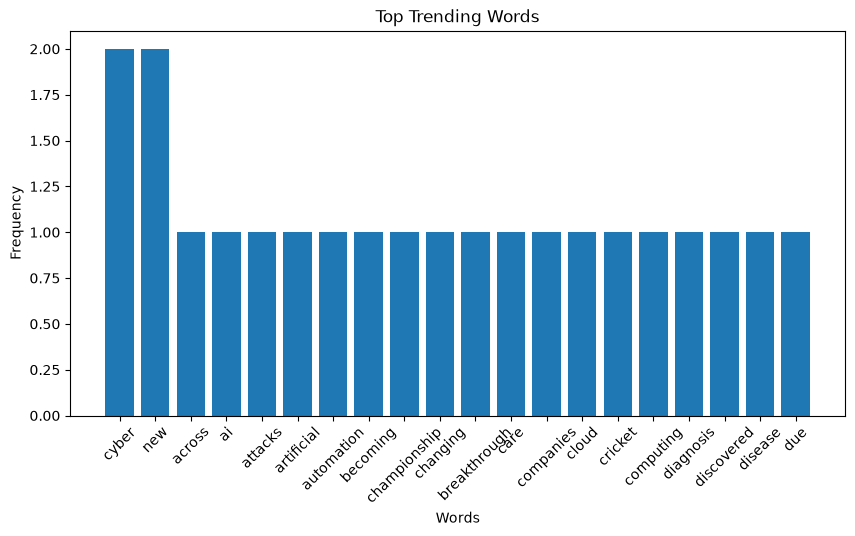

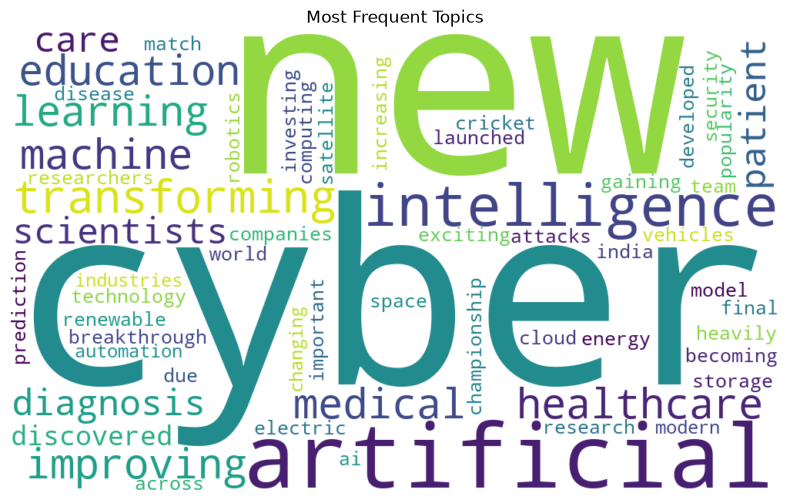


Top Keywords (TF-IDF)

- across
- ai
- artificial
- automation
- becoming
- breakthrough
- care
- championship
- cyber
- new

Program Executed Successfully.


In [1]:
"""PROGRAM 10
Using web scraping tools, extract the content from a set of web pages (e.g.,
news, blogs). Analyse the text to identify trends and topics. (use Python/R/any
other tool).
Text Mining and Topic Identification (Offline Version)"""

import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

nltk.download('stopwords')

articles = [
"Artificial Intelligence is transforming healthcare and education.",
"Machine learning is improving medical diagnosis and patient care.",
"Scientists discovered a breakthrough in renewable energy storage.",
"The cricket team won the championship after an exciting final match.",
"Technology companies are investing heavily in cloud computing.",
"Cyber security is becoming important due to increasing cyber attacks.",
"Researchers developed a new AI model for disease prediction.",
"Electric vehicles are gaining popularity across the world.",
"India launched a new satellite for space research.",
"Robotics and automation are changing modern industries."
]

combined_text = " ".join(articles)
print("Sample Text:\n")
print(combined_text[:300])

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

cleaned_text = clean_text(combined_text)
vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform([cleaned_text])
words = vectorizer.get_feature_names_out()
counts = X.toarray().flatten()

df = pd.DataFrame({
    "Word": words,
    "Count": counts
})

df = df.sort_values(by="Count", ascending=False)
print("\nTop Trending Words\n")
print(df)

plt.figure(figsize=(10,5))
plt.bar(df["Word"], df["Count"])
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top Trending Words")
plt.show()

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white"

).generate(cleaned_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Topics")
plt.show()

tfidf = TfidfVectorizer(max_features=10)
tfidf_matrix = tfidf.fit_transform([cleaned_text])
keywords = tfidf.get_feature_names_out()
print("\nTop Keywords (TF-IDF)\n")
for word in keywords:
    print("-", word)
print("\nProgram Executed Successfully.")